First part stolen from: https://www.kaggle.com/code/stpeteishii/dog-cat-zero-shot-classification

We look through some existing code working with CLIP for inspiration. We end up messing with embeddings generated from CLIP to compare dogs and it appears to do better than a more mundane image comparison.

# Dog/Cat Zero-Shot Classification
with clip-vit-base-patch16

In [1]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
from transformers import CLIPProcessor, CLIPModel

In [5]:
!unzip DogOrCat.zip

Streaming output truncated to the last 5000 lines.
  inflating: training_set/training_set/cats/cat.3704.jpg  
  inflating: training_set/training_set/cats/cat.3705.jpg  
  inflating: training_set/training_set/cats/cat.3706.jpg  
  inflating: training_set/training_set/cats/cat.3707.jpg  
  inflating: training_set/training_set/cats/cat.3708.jpg  
  inflating: training_set/training_set/cats/cat.3709.jpg  
  inflating: training_set/training_set/cats/cat.371.jpg  
  inflating: training_set/training_set/cats/cat.3710.jpg  
  inflating: training_set/training_set/cats/cat.3711.jpg  
  inflating: training_set/training_set/cats/cat.3712.jpg  
  inflating: training_set/training_set/cats/cat.3713.jpg  
  inflating: training_set/training_set/cats/cat.3714.jpg  
  inflating: training_set/training_set/cats/cat.3715.jpg  
  inflating: training_set/training_set/cats/cat.3716.jpg  
  inflating: training_set/training_set/cats/cat.3717.jpg  
  inflating: training_set/training_set/cats/cat.3718.jpg  
  infl

In [6]:
paths0=[]
for dirname, _, filenames in os.walk('test_set/test_set'):
    for filename in filenames:
        paths0+=[(os.path.join(dirname, filename))]
paths=random.sample(paths0,6)

In [7]:
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch16")
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch16")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/599M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/599M [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


...

tokenizer_config.json:   0%|          | 0.00/905 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

## classify dog/cat


dog [0.998, 0.002]


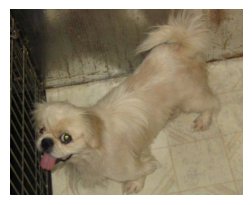


cat [0.0028, 0.9972]


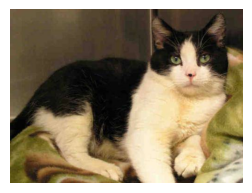


dog [0.9984, 0.0016]


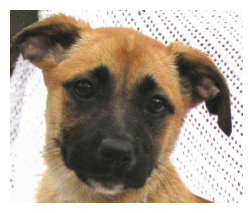


dog [0.9984, 0.0016]


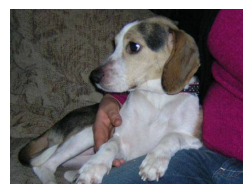


dog [0.9987, 0.0013]


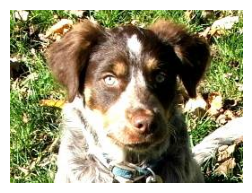


dog [0.9995, 0.0005]


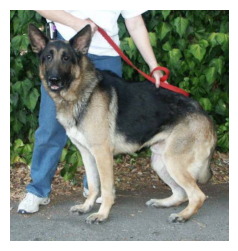

In [8]:
for path in paths:
    image=plt.imread(path)
    inputs = processor(text=["dog","cat",], images=image, return_tensors="pt", padding=True)
    outputs = model(**inputs)
    logits_per_image = outputs.logits_per_image
    probs = logits_per_image.softmax(dim=1).tolist()[0]
    probs2 = [round(value,4) for value in probs]
    print()
    print(["dog","cat"][np.argmax(probs2)],probs2)
    image=plt.imread(path)
    plt.figure(figsize=(3,3))
    plt.imshow(image)
    plt.axis('off')
    plt.show()

## classify standing/sitting


standing [0.8137, 0.1863]


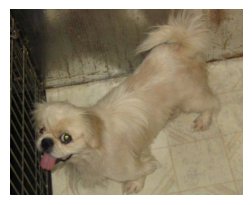


sitting [0.1888, 0.8112]


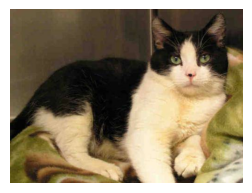


sitting [0.4168, 0.5832]


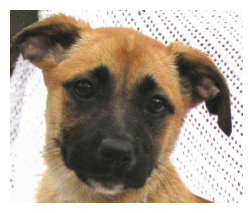


sitting [0.0656, 0.9344]


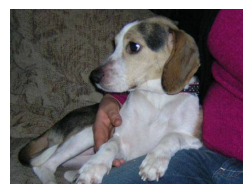


standing [0.5718, 0.4282]


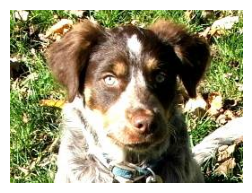


standing [0.5625, 0.4375]


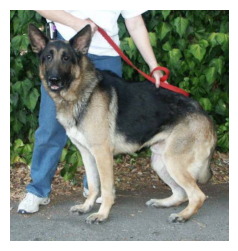

In [9]:
for path in paths:
    image=plt.imread(path)
    inputs = processor(text=["standing","sitting"], images=image, return_tensors="pt", padding=True)
    outputs = model(**inputs)
    logits_per_image = outputs.logits_per_image
    probs = logits_per_image.softmax(dim=1).tolist()[0]
    probs2 = [round(value,4) for value in probs]
    print()
    print(["standing","sitting"][np.argmax(probs2)],probs2)
    image=plt.imread(path)
    plt.figure(figsize=(3,3))
    plt.imshow(image)
    plt.axis('off')
    plt.show()

Wow, those were some cool examples of what CLIP can do! (((o(*ﾟ▽ﾟ*)o)))

Time to do something completely different.

In [132]:
#extract dogs
dogs=[]
for dirname, _, filenames in os.walk('training_set/training_set/dogs'):
    for filename in filenames[:500]:
        dogs+=[(os.path.join(dirname, filename))]

In [133]:
#get embedding from CLIP
def get_image_embedding(path):
    image = plt.imread(path)
    inputs = processor(images=image, return_tensors="pt")
    with torch.no_grad():
      embedding = model.get_image_features(processor(images=image, return_tensors="pt")["pixel_values"])
      embedding = embedding / embedding.norm(p=2, dim=-1, keepdim=True)
    return embedding

In [134]:
#get you a list o' dog captions
embeddings = []
for dog in dogs:
    emb = get_image_embedding(dog)
    embeddings.append(emb)

embeddings = torch.vstack(embeddings)
print("Index built:", embeddings.shape)

Index built: torch.Size([500, 512])


In [135]:
def find_most_similar(query_path, image_paths, embeddings):

  query_emb = get_image_embedding(query_path)


  sims = torch.matmul(embeddings, query_emb.T).squeeze()

  if query_path in image_paths:
    idx = image_paths.index(query_path)
    sims[idx] = -1  #evict same

  best_idx = sims.argmax().item()
  best_match_path = image_paths[best_idx]
  best_score = sims[best_idx].item()

  plt.figure(figsize=(10,5))
  plt.subplot(1,2,1)
  plt.imshow(plt.imread(query_path))
  plt.title("Query Image")
  plt.axis("off")

  plt.subplot(1,2,2)
  plt.imshow(plt.imread(best_match_path))
  plt.title("Most Similar Image")
  plt.axis("off")
  plt.show()


Both on grassy ground, looking at camera suspiciously.

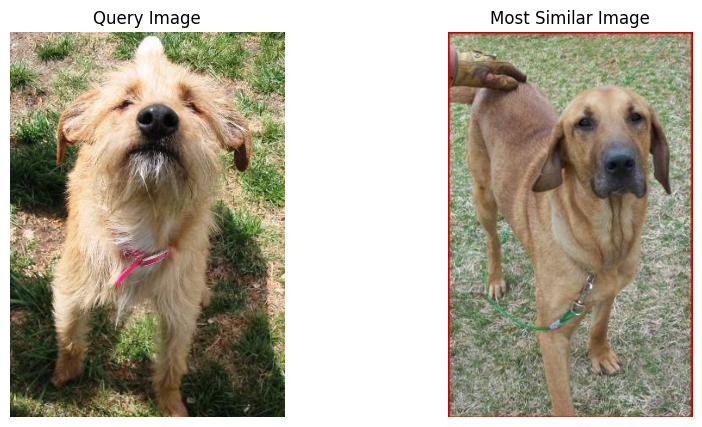

In [136]:
find_most_similar(dogs[1], dogs, embeddings)

Both small vessels in a large world.

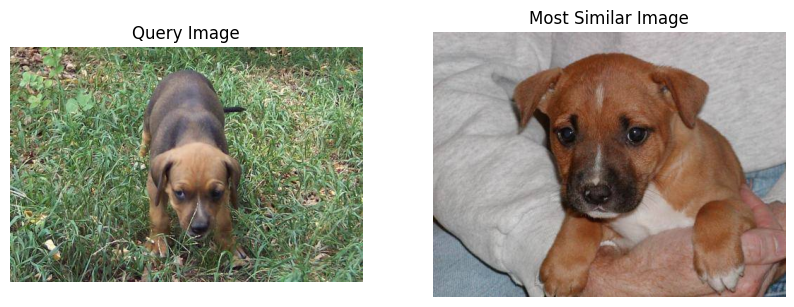

In [137]:
find_most_similar(dogs[2], dogs, embeddings)

Both have owner standing behind while they sit and pant.

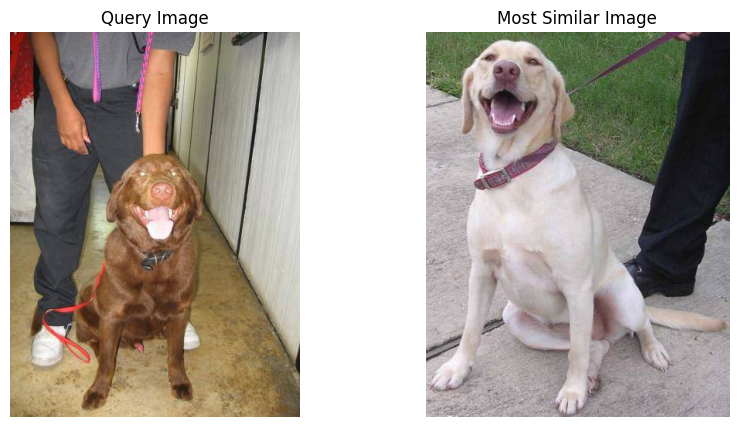

In [138]:
find_most_similar(dogs[3], dogs, embeddings)

Now let's try it without any fancy models.

In [139]:
from PIL import Image

pixel_size = (224, 224) #squish size

#get embedding from CLIP
def get_raw_image_embedding(path):
  img = Image.open(path).convert("RGB").resize(pixel_size)
  embedding = np.asarray(img).astype(np.float32).flatten()
  embedding = embedding / 255.0
  return embedding

In [140]:
#get you a list o' dog captions
pixel_embeddings = {} #filename,flattened pixel vector
for dog in dogs:
    emb = get_raw_image_embedding(dog)
    pixel_embeddings[dog] = emb


In [142]:
def cosine_sim(a, b):
  return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

def raw_most_similar(query_path, embeddings):
  query = embeddings[query_path]
  best_path = None
  best_score = -1

  for path, emb in embeddings.items():
    if path == query_path:
      continue   #skip self
    score = sims = cosine_sim(query, emb)
    if score > best_score:
      best_score = score
      best_path = path

  plt.figure(figsize=(10,5))
  plt.subplot(1,2,1)
  plt.imshow(plt.imread(query_path))
  plt.title("Query Image")
  plt.axis("off")

  plt.subplot(1,2,2)
  plt.imshow(plt.imread(best_path))
  plt.title("Most Similar Image")
  plt.axis("off")
  plt.show()

Kind of looking up at camera and wispy, completely different environment.

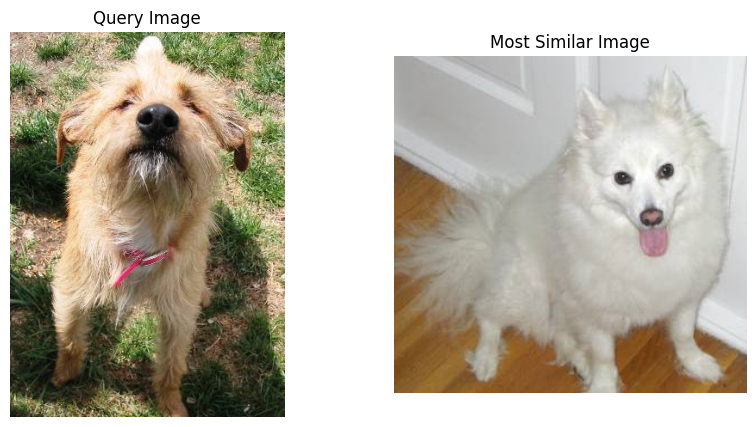

In [143]:
raw_most_similar(dogs[1], pixel_embeddings)

Vertically aligned to camera, fairly different overall color.

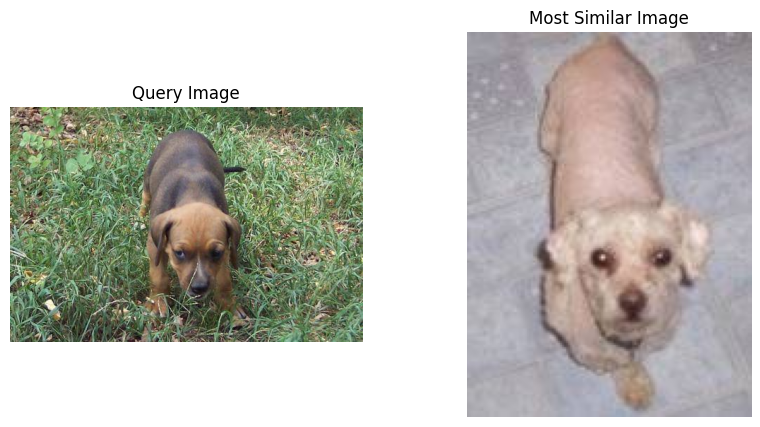

In [144]:
raw_most_similar(dogs[2], pixel_embeddings)

That's just the same dog again!

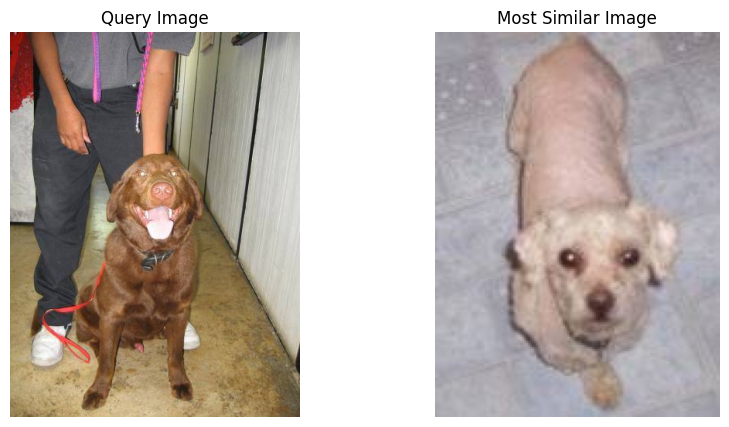

In [147]:
raw_most_similar(dogs[3], pixel_embeddings)

The pixel comparison kind of got the dog verticallity right, but CLIP captured more similarities like the suspicious look, youthful dog, and panting while sitting with leash. It takes much longer to get an embedding for an image with CLIP, however.